In [ ]:
import sys, os

sys.path.insert(0, "../")

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import time
from pycbc.types import FrequencySeries
from modules.Classes_v2 import Precessing as P2, LensingGeo
from modules.Classes_v3 import Precessing as P3
from modules.Classes_v4 import Precessing as P4
from modules.Classes_v5 import Precessing as P5
from modules.default_params_v3 import *
from modules.functions_v3 import calculate_cosJN, mismatch_from_strains

plt.rcParams["figure.dpi"] = 200

/Users/fairytien/Documents/TEXAS_Bridge_2324/code/lensing_and_precession/notebooks/../modules/Classes_v2.py:23: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):
/Users/fairytien/Documents/TEXAS_Bridge_2324/code/lensing_and_precession/notebooks/../modules/Classes_v2.py:23: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):


In [2]:
params_Ben = RP_params_1.copy()

# Use Ben's angles
params_Ben.update(
    {
        "theta_S": np.pi / 3,
        "phi_S": np.pi / 4,
        "theta_J": np.pi / 6,
        "phi_J": np.pi / 3,
        "theta_tilde": 8,
        "omega_tilde": 3.55,
        "gamma_P": 2.399,
    }
)
cos_JN = calculate_cosJN(
    params_Ben["phi_S"],
    params_Ben["theta_S"],
    params_Ben["phi_J"],
    params_Ben["theta_J"],
)
print(cos_JN)

order of arguments: phi_S, theta_S, phi_J, theta_J
0.8512708537611233


In [3]:
p2_Ben = P2(params_Ben)
p3_Ben = P3(params_Ben)

# Frequency array
f_min = 20
f_cut = p2_Ben.f_cut()
delta_f = 0.25
f_arr = np.arange(f_min, f_cut, delta_f)

# Compare different tolerances for P2

P2 Computation times (s):
     rtol=1e-10, atol=1e-11: 0.09385s
  Default: rtol=1.49e-08, atol=1.49e-08: 0.05543s
     rtol=1e-07, atol=1e-08: 0.05288s
     rtol=1e-06, atol=1e-07: 0.04184s
    rtol=0.0001, atol=1e-05: 0.02457s
    rtol=0.001, atol=0.0001: 0.01903s


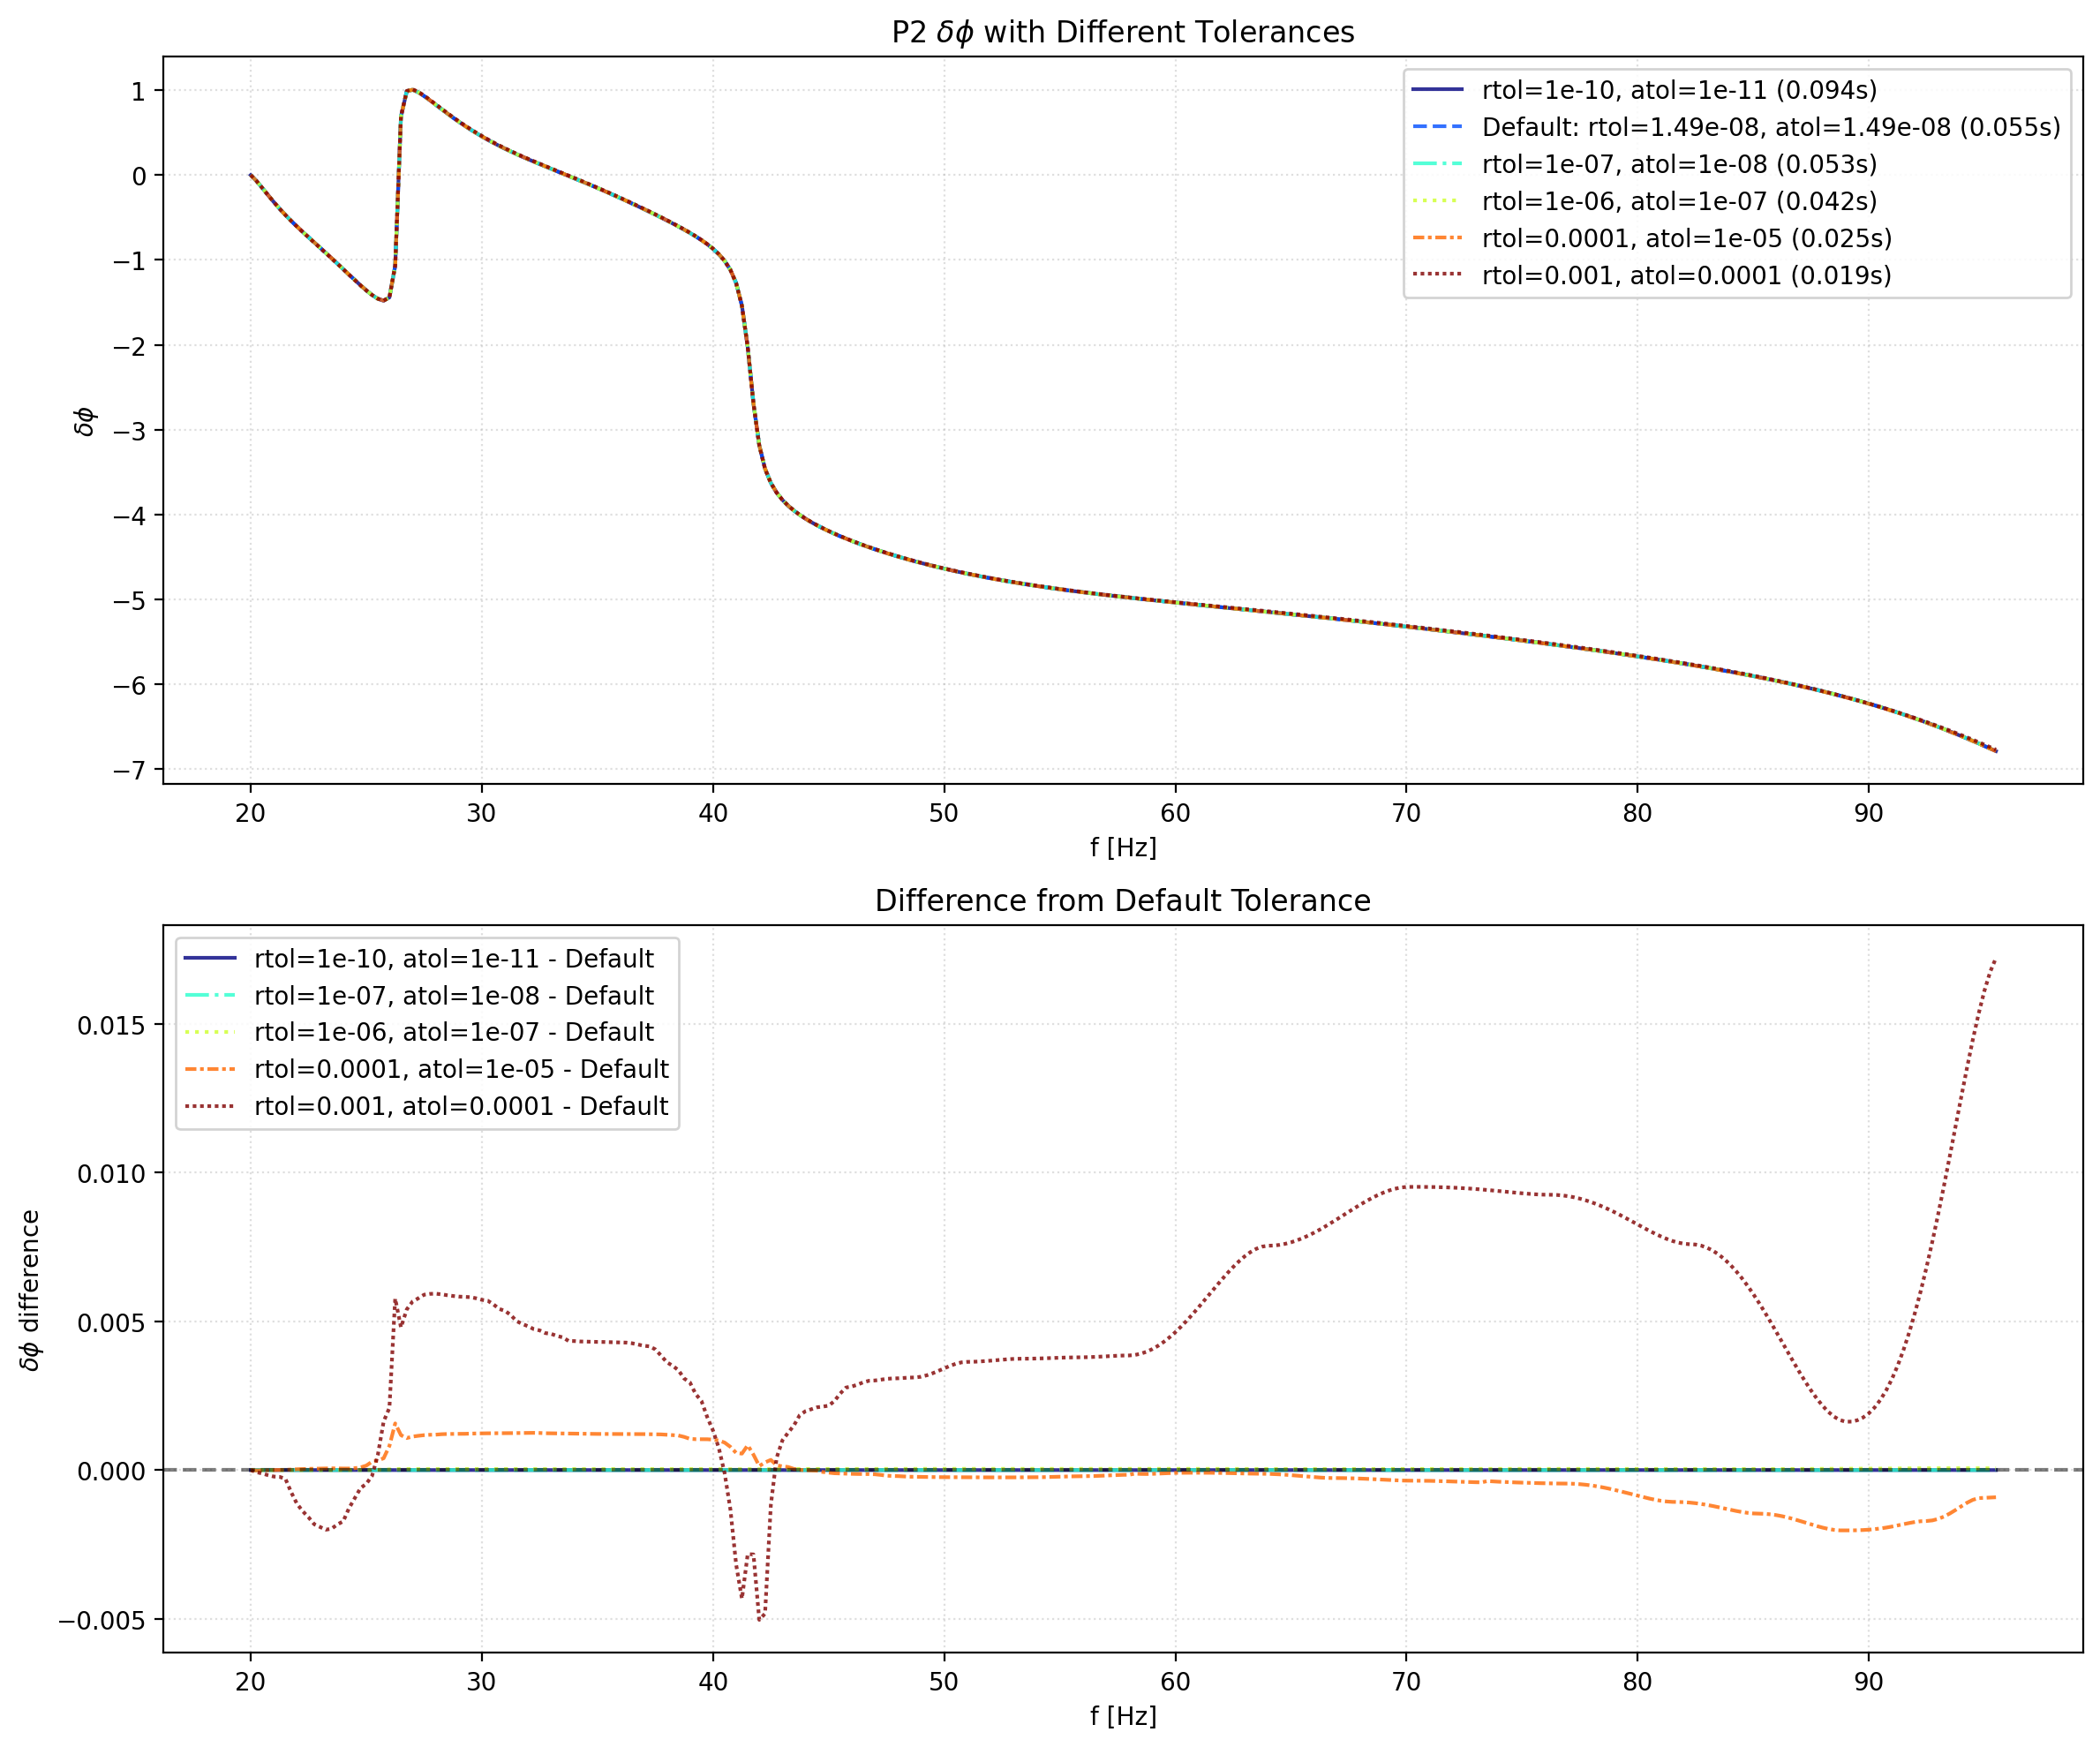


Maximum differences from Default:
     rtol=1e-10, atol=1e-11: 6.28e-07
     rtol=1e-07, atol=1e-08: 2.45e-06
     rtol=1e-06, atol=1e-07: 6.30e-05
    rtol=0.0001, atol=1e-05: 2.03e-03
    rtol=0.001, atol=0.0001: 1.72e-02


In [ ]:
# Test different tolerances for P2 and plot phase_delta_phi

P2_DEFAULT_RTOL = 1.49012e-8
P2_DEFAULT_ATOL = 1.49012e-8
# Define different tolerance combinations
tolerance_sets = [
    (1e-10, 1e-11),
    (None, None),  # odeint defaults
    (1e-7, 1e-8),
    (1e-6, 1e-7),
    (1e-4, 1e-5),
    (1e-3, 1e-4),
]

# Define linestyles for each tolerance set
linestyles = [
    "-",
    "--",
    "-.",
    ":",
    (0, (3, 1, 1, 1)),  # dash-dot-dot
    (0, (1, 1)),  # densely dotted
]
# If more tolerance sets than linestyles, repeat styles
if len(linestyles) < len(tolerance_sets):
    from itertools import cycle, islice

    linestyles = list(islice(cycle(linestyles), len(tolerance_sets)))

# Compute phase_delta_phi for each tolerance set
p2_results = {}
p2_timings = {}

for rtol, atol in tolerance_sets:
    # Create label from tolerance values
    if rtol is None and atol is None:
        default_label = "Default: rtol={:.3g}, atol={:.3g}".format(
            P2_DEFAULT_RTOL, P2_DEFAULT_ATOL
        )
        label = default_label
    else:
        label = "rtol={:.3g}, atol={:.3g}".format(rtol, atol)

    t0 = time.time()
    phase = np.atleast_1d(p2_Ben.phase_delta_phi(f_arr, rtol=rtol, atol=atol))
    p2_timings[label] = time.time() - t0
    p2_results[label] = phase

# Print timings
print("P2 Computation times (s):")
for label in p2_timings:
    print(f"  {label:>25}: {p2_timings[label]:.5f}s")

# Plot all tolerance results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: All tolerance curves
colors = plt.cm.jet(np.linspace(0, 1, len(tolerance_sets)))
for i, label in enumerate(p2_results.keys()):
    ax1.plot(
        f_arr,
        p2_results[label],
        label=f"{label} ({p2_timings[label]:.3f}s)",
        color=colors[i],
        lw=1.5,
        alpha=0.8,
        linestyle=linestyles[i],
    )

ax1.set_xlabel("f [Hz]")
ax1.set_ylabel("$\delta\phi$")
ax1.set_title("P2 $\delta\phi$ with Different Tolerances")
# Overlay the legend on the plot (not outside)
ax1.legend(loc="best", framealpha=0.85)
ax1.grid(True, ls=":", alpha=0.4)

# Plot 2: Differences from default (if default exists)
if default_label in p2_results:
    default_phase = p2_results[default_label]
    for i, label in enumerate(p2_results.keys()):
        if label != default_label:
            diff = p2_results[label] - default_phase
            ax2.plot(
                f_arr,
                diff,
                label=f"{label} - Default",
                color=colors[i],
                lw=1.5,
                alpha=0.8,
                linestyle=linestyles[i],
            )

ax2.set_xlabel("f [Hz]")
ax2.set_ylabel("$\delta\phi$ difference")
ax2.set_title("Difference from Default Tolerance")
# Overlay the legend on the plot (not outside)
ax2.legend(loc="best", framealpha=0.85)
ax2.grid(True, ls=":", alpha=0.4)
ax2.axhline(y=0, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Print maximum differences from default
if default_label in p2_results:
    print("\nMaximum differences from Default:")
    for label in p2_results.keys():
        if label != default_label:
            max_diff = np.max(np.abs(p2_results[label] - default_phase))
            print(f"  {label:>25}: {max_diff:.2e}")

# Compare P2 (v2), P3 (v3), and P4 (various `solve_ivp` methods)

Computation times (s):
  P2-odeint: 0.05720s
  P3-cumtrapz: 0.00103s
  P5-quad: 0.49837s
  P4-RK45: 0.07241s
  P4-RK23: 0.20743s
  P4-DOP853: 0.09427s
  P4-LSODA: 0.06908s


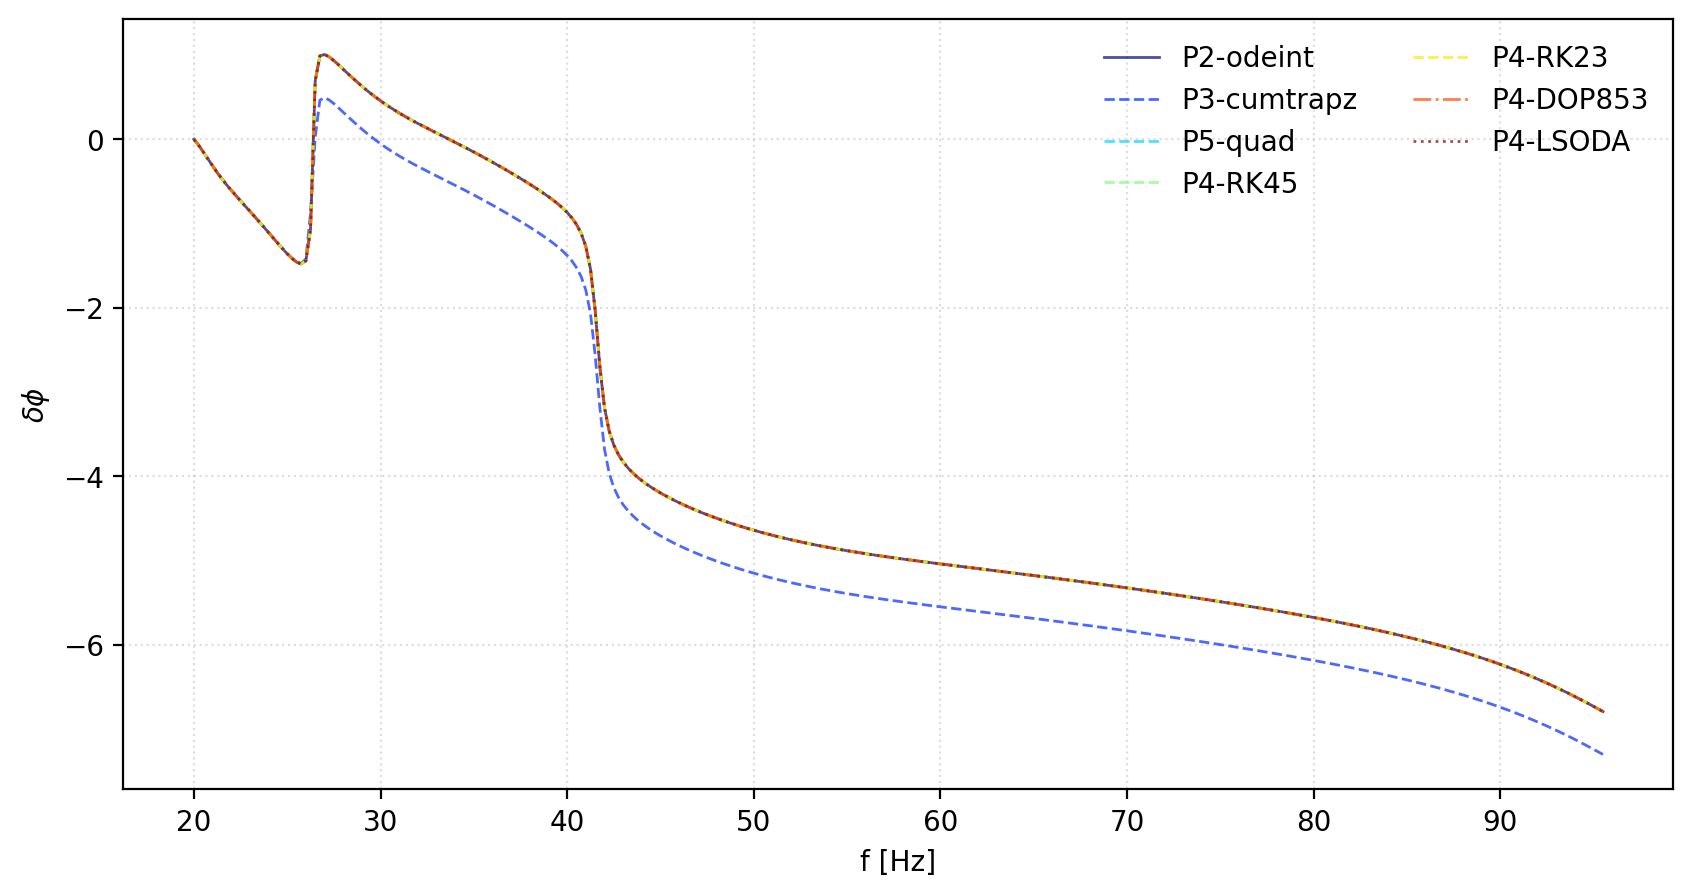

In [15]:
# Compare P2 (v2), P3 (v3), and P4 (various solve_ivp methods)
# Time each computation and plot with distinct styles

p2_Ben = P2(params_Ben)
p3_Ben = P3(params_Ben)
p4_Ben = P4(params_Ben)
p5_Ben = P5(params_Ben)

results = {}
timings = {}

# P2
t0 = time.time()
phase2 = np.atleast_1d(p2_Ben.phase_delta_phi(f_arr, rtol=1e-6, atol=1e-7))
timings["P2-odeint"] = time.time() - t0
results["P2-odeint"] = phase2

# P3
t0 = time.time()
phase3 = np.atleast_1d(p3_Ben.phase_delta_phi(f_arr))
timings["P3-cumtrapz"] = time.time() - t0
results["P3-cumtrapz"] = phase3

# P4 per-method timing
methods = ["RK45", "RK23", "DOP853", "LSODA"]
# methods = ["RK23", "DOP853"]
for m in methods:
    t0 = time.time()
    results[f"P4-{m}"] = np.atleast_1d(
        p4_Ben.phase_delta_phi(f_arr, ivp_method=m, rtol=1e-6, atol=1e-7)
    )
    timings[f"P4-{m}"] = time.time() - t0

# P5
t0 = time.time()
phase5 = np.atleast_1d(p5_Ben.phase_delta_phi(f_arr, epsrel=1e-6, epsabs=1e-7))
timings["P5-quad"] = time.time() - t0
results["P5-quad"] = phase5

# Print timings
print("Computation times (s):")
for k in ["P2-odeint", "P3-cumtrapz", "P5-quad"] + [f"P4-{m}" for m in methods]:
    print(f"  {k:>7}: {timings[k]:.5f}s")


# Assign colors to each method in plot order
plot_order = ["P2-odeint", "P3-cumtrapz", "P5-quad"] + [f"P4-{m}" for m in methods]
colors = plt.cm.jet(np.linspace(0, 1, len(plot_order)))

# Style map (line styles)
style_map = {
    "P2-odeint": "-",
    "P3-cumtrapz": "--",
    "P5-quad": "--",
    "P4-RK45": "--",
    "P4-RK23": "--",
    "P4-DOP853": "-.",
    "P4-LSODA": ":",
}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for i, key in enumerate(plot_order):
    ls = style_map.get(key, "-")
    ax.plot(f_arr, results[key], label=key, lw=1, alpha=0.7, color=colors[i], ls=ls)

ax.set_xlabel("f [Hz]")
ax.set_ylabel("$\delta\phi$")
ax.legend(ncol=2, frameon=False)
ax.grid(True, ls=":", alpha=0.4)
plt.show()

In [9]:
# Mismatch and fractional differences: compare all to P2 only

# Build strains (FrequencySeries) for P2, P3
h2 = p2_Ben.strain(f_arr, delta_f=delta_f, frequencySeries=True)
h3 = p3_Ben.strain(f_arr, delta_f=delta_f, frequencySeries=True)

# Build strains for P4 per method by plugging each phase_delta_phi into the formula
h4 = {}
for m in ["RK45", "RK23", "DOP853", "LSODA"]:
    try:
        h4[m] = p4_Ben.strain(
            f_arr, delta_f=delta_f, ivp_method=m, rtol=1e-8, atol=1e-10
        )
    except Exception as e:
        print(f"P4-{m} strain failed: {e}")

# Compute mismatches (only vs P2)
mm = {}
mm["P2_vs_P3"] = mismatch_from_strains(h2, h3, f_min=f_min, delta_f=delta_f)["mismatch"]
for m, h in h4.items():
    mm[f"P2_vs_P4-{m}"] = mismatch_from_strains(h2, h, f_min=f_min, delta_f=delta_f)[
        "mismatch"
    ]

print("Mismatches (vs P2):")
for k, v in mm.items():
    print(f"  {k:>14}: {v:.6e}")

Mismatches (vs P2):
        P2_vs_P3: 1.217345e-02
   P2_vs_P4-RK45: 5.795364e-14
   P2_vs_P4-RK23: 2.731149e-14
  P2_vs_P4-DOP853: 2.442491e-14
  P2_vs_P4-LSODA: 2.675637e-14


# Check the convergence of P2, P3, P4 with different tolerances

In [30]:
# Comprehensive tolerance convergence study for P2, P3, P4

# Define tolerance sets to test (logarithmically spaced)
tolerance_sets = [
    ("Default", None, None),  # Default tolerances
    ("Loose", 1e-2, 1e-5),
    ("Medium", 1e-5, 1e-7),
    ("Tight", 1e-6, 1e-8),
    ("Very Tight", 1e-8, 1e-10),
]

# Test P2 with different tolerances
print("Testing P2 tolerance convergence...")
p2_results = {}
p2_timings = {}

for name, rtol, atol in tolerance_sets:
    t0 = time.time()
    phase = np.atleast_1d(p2_Ben.phase_delta_phi(f_arr, rtol=rtol, atol=atol))
    p2_timings[name] = time.time() - t0
    p2_results[name] = phase

# Test P3 (uses cumulative_trapezoid - no tolerance control)
print("Testing P3...")
t0 = time.time()
p3_phase = np.atleast_1d(p3_Ben.phase_delta_phi(f_arr))
p3_timing = time.time() - t0

# Test P4 with different tolerances (using RK45 method)
print("Testing P4 tolerance convergence...")
p4_results = {}
p4_timings = {}
for name, rtol, atol in tolerance_sets:
    if rtol is None and atol is None:
        rtol = 1e-3
        atol = 1e-6
    for m in methods:
        t0 = time.time()
        phase = np.atleast_1d(
            p4_Ben.phase_delta_phi(f_arr, ivp_method=m, rtol=rtol, atol=atol)
        )
        p4_timings[f"{name}-{m}"] = time.time() - t0
        p4_results[f"{name}-{m}"] = phase


# Print timing summary
print("\nTiming Summary (seconds):")
print("P2:")
for name in p2_timings:
    print(f"  {name:>12}: {p2_timings[name]:.5f}s")
print(f"P3: {'Default':>12}: {p3_timing:.5f}s")
print("P4:")
for name in p4_timings:
    print(f"  {name:>12}: {p4_timings[name]:.5f}s")

Testing P2 tolerance convergence...
Testing P3...
Testing P4 tolerance convergence...

Timing Summary (seconds):
P2:
       Default: 0.20596s
         Loose: 0.02517s
        Medium: 0.06413s
         Tight: 0.07327s
    Very Tight: 0.08827s
P3:      Default: 0.00346s
P4:
  Default-RK45: 0.02443s
  Default-RK23: 0.04183s
  Default-DOP853: 0.03942s
  Default-LSODA: 0.03679s
    Loose-RK45: 0.01641s
    Loose-RK23: 0.02053s
  Loose-DOP853: 0.04399s
   Loose-LSODA: 0.02325s
   Medium-RK45: 0.04076s
   Medium-RK23: 0.11112s
  Medium-DOP853: 0.06630s
  Medium-LSODA: 0.05410s
    Tight-RK45: 0.06207s
    Tight-RK23: 0.21547s
  Tight-DOP853: 0.08286s
   Tight-LSODA: 0.06716s
  Very Tight-RK45: 0.12613s
  Very Tight-RK23: 1.06582s
  Very Tight-DOP853: 0.16006s
  Very Tight-LSODA: 0.10183s


Convergence Analysis (Maximum differences from Very Tight reference):

P2 convergence:
       Default: 5.66e-07
         Loose: 1.77e-01
        Medium: 2.66e-04
         Tight: 2.00e-05

P4 convergence (by method):
  Method: RK45
         Default: 2.88e+00
           Loose: 2.65e+00
          Medium: 3.69e-04
           Tight: 2.86e-05
  Method: RK23
         Default: 5.33e-03
           Loose: 3.74e-02
          Medium: 4.51e-05
           Tight: 5.13e-06
  Method: DOP853
         Default: 1.09e+01
           Loose: 9.17e-02
          Medium: 1.27e-04
           Tight: 8.80e-06
  Method: LSODA
         Default: 1.27e-02
           Loose: 1.48e-01
          Medium: 2.35e-04
           Tight: 2.00e-05

P3 vs P2 Very Tight: 6.69e-01
P3 vs P4 Very Tight (RK45): 6.69e-01
P3 vs P4 Very Tight (RK23): 6.69e-01
P3 vs P4 Very Tight (DOP853): 6.69e-01
P3 vs P4 Very Tight (LSODA): 6.69e-01


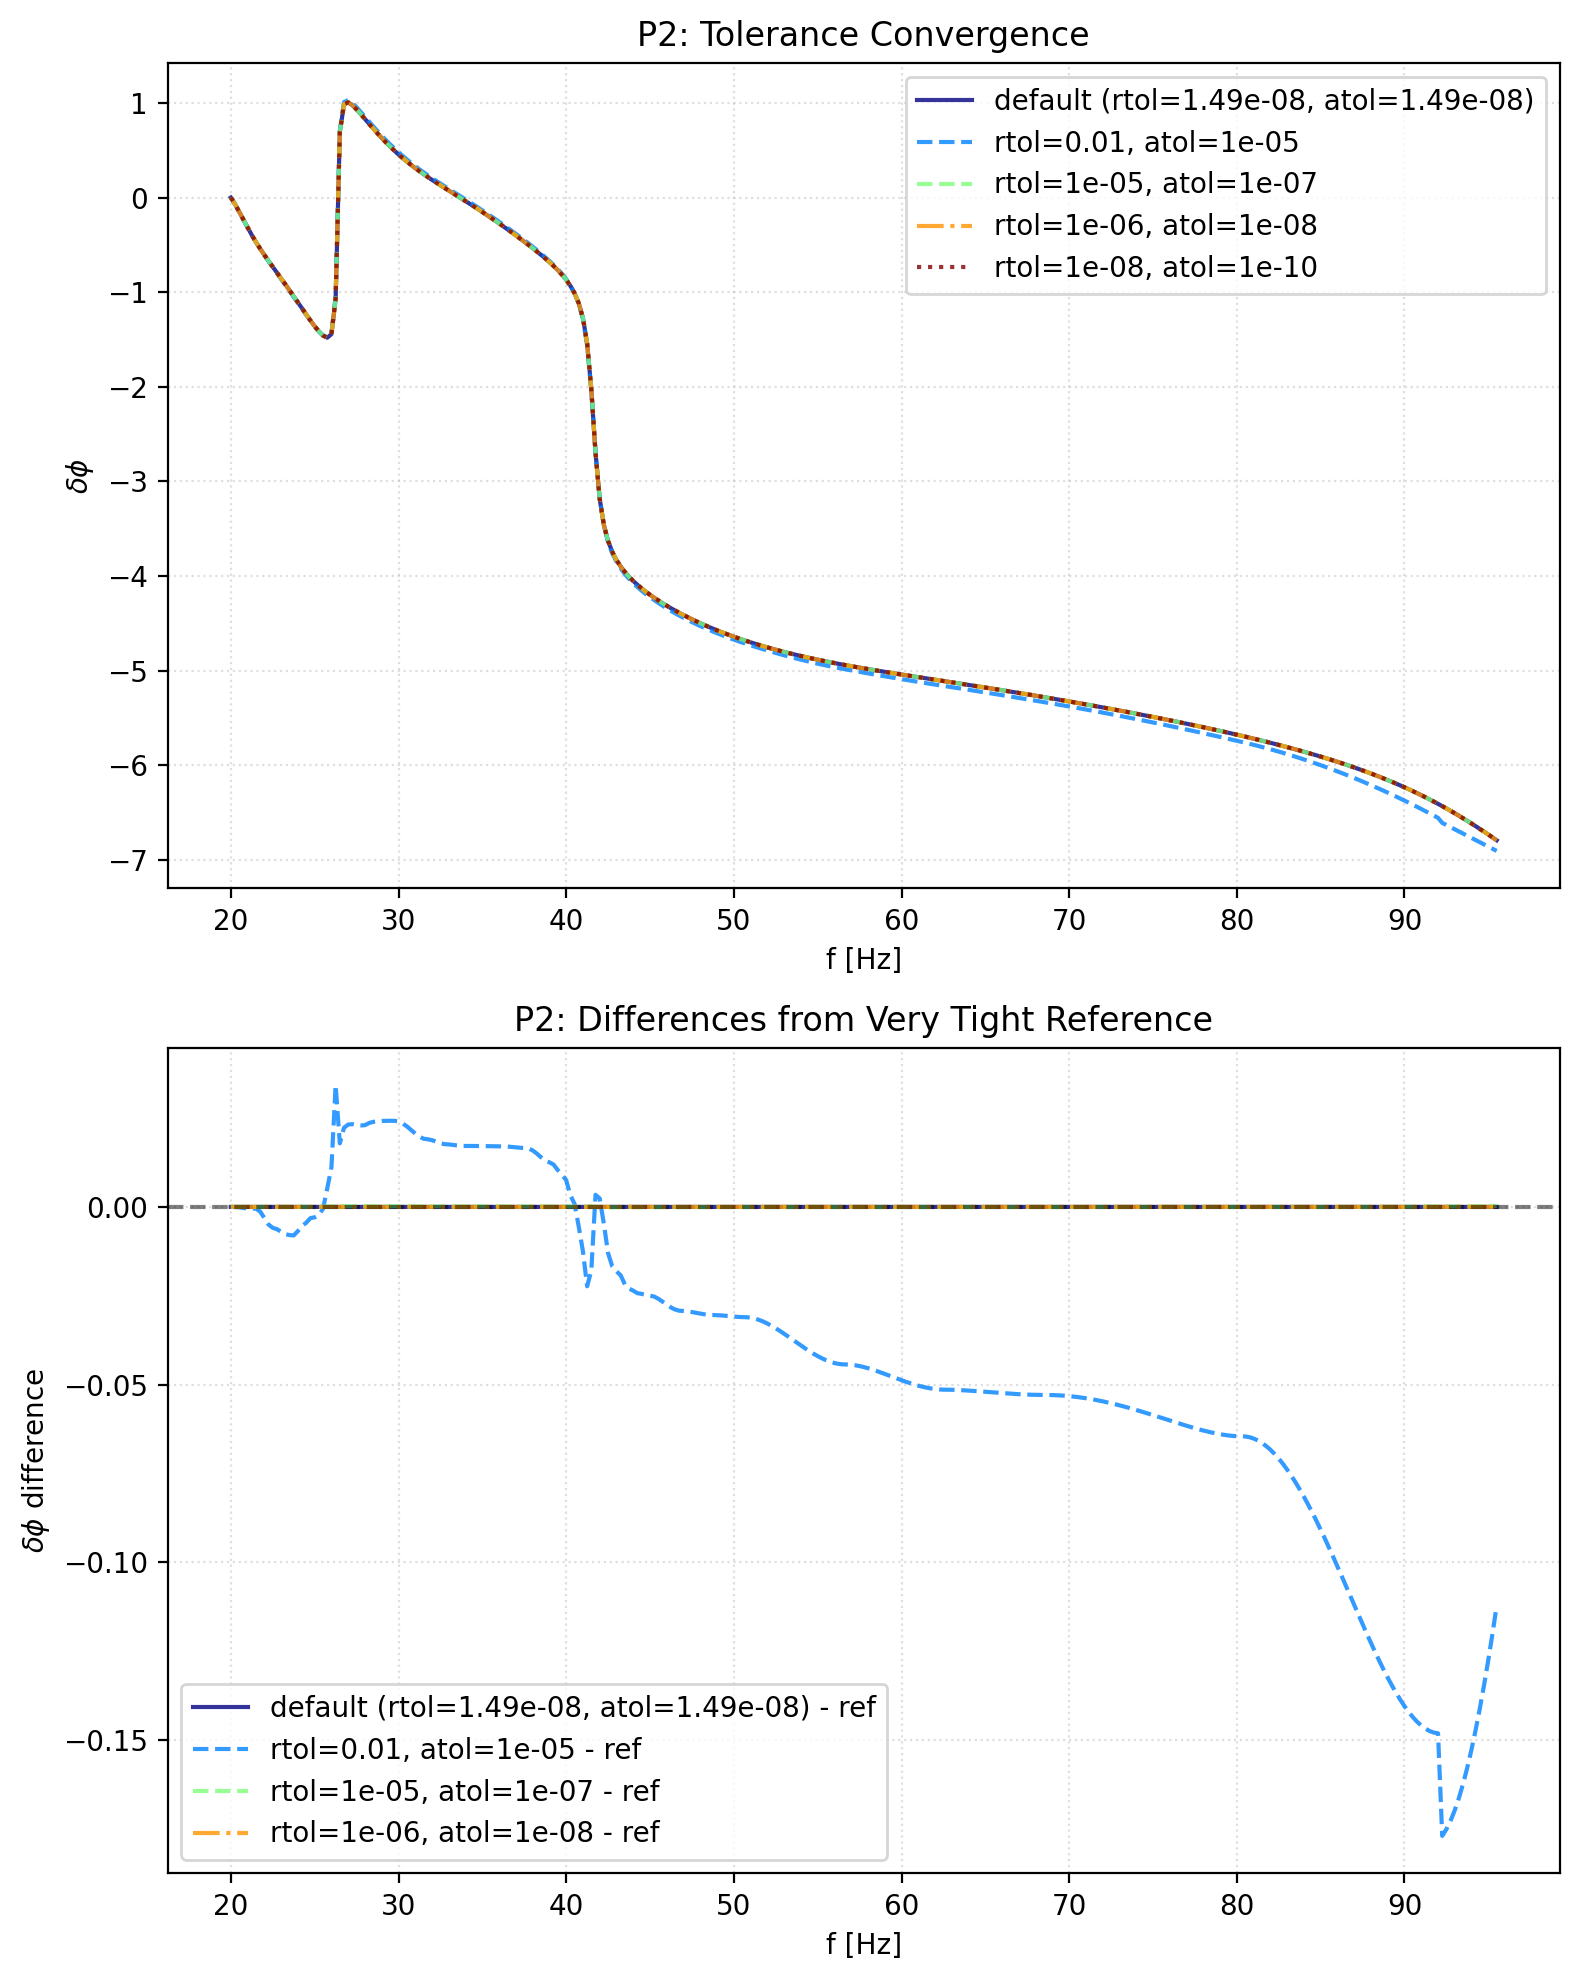

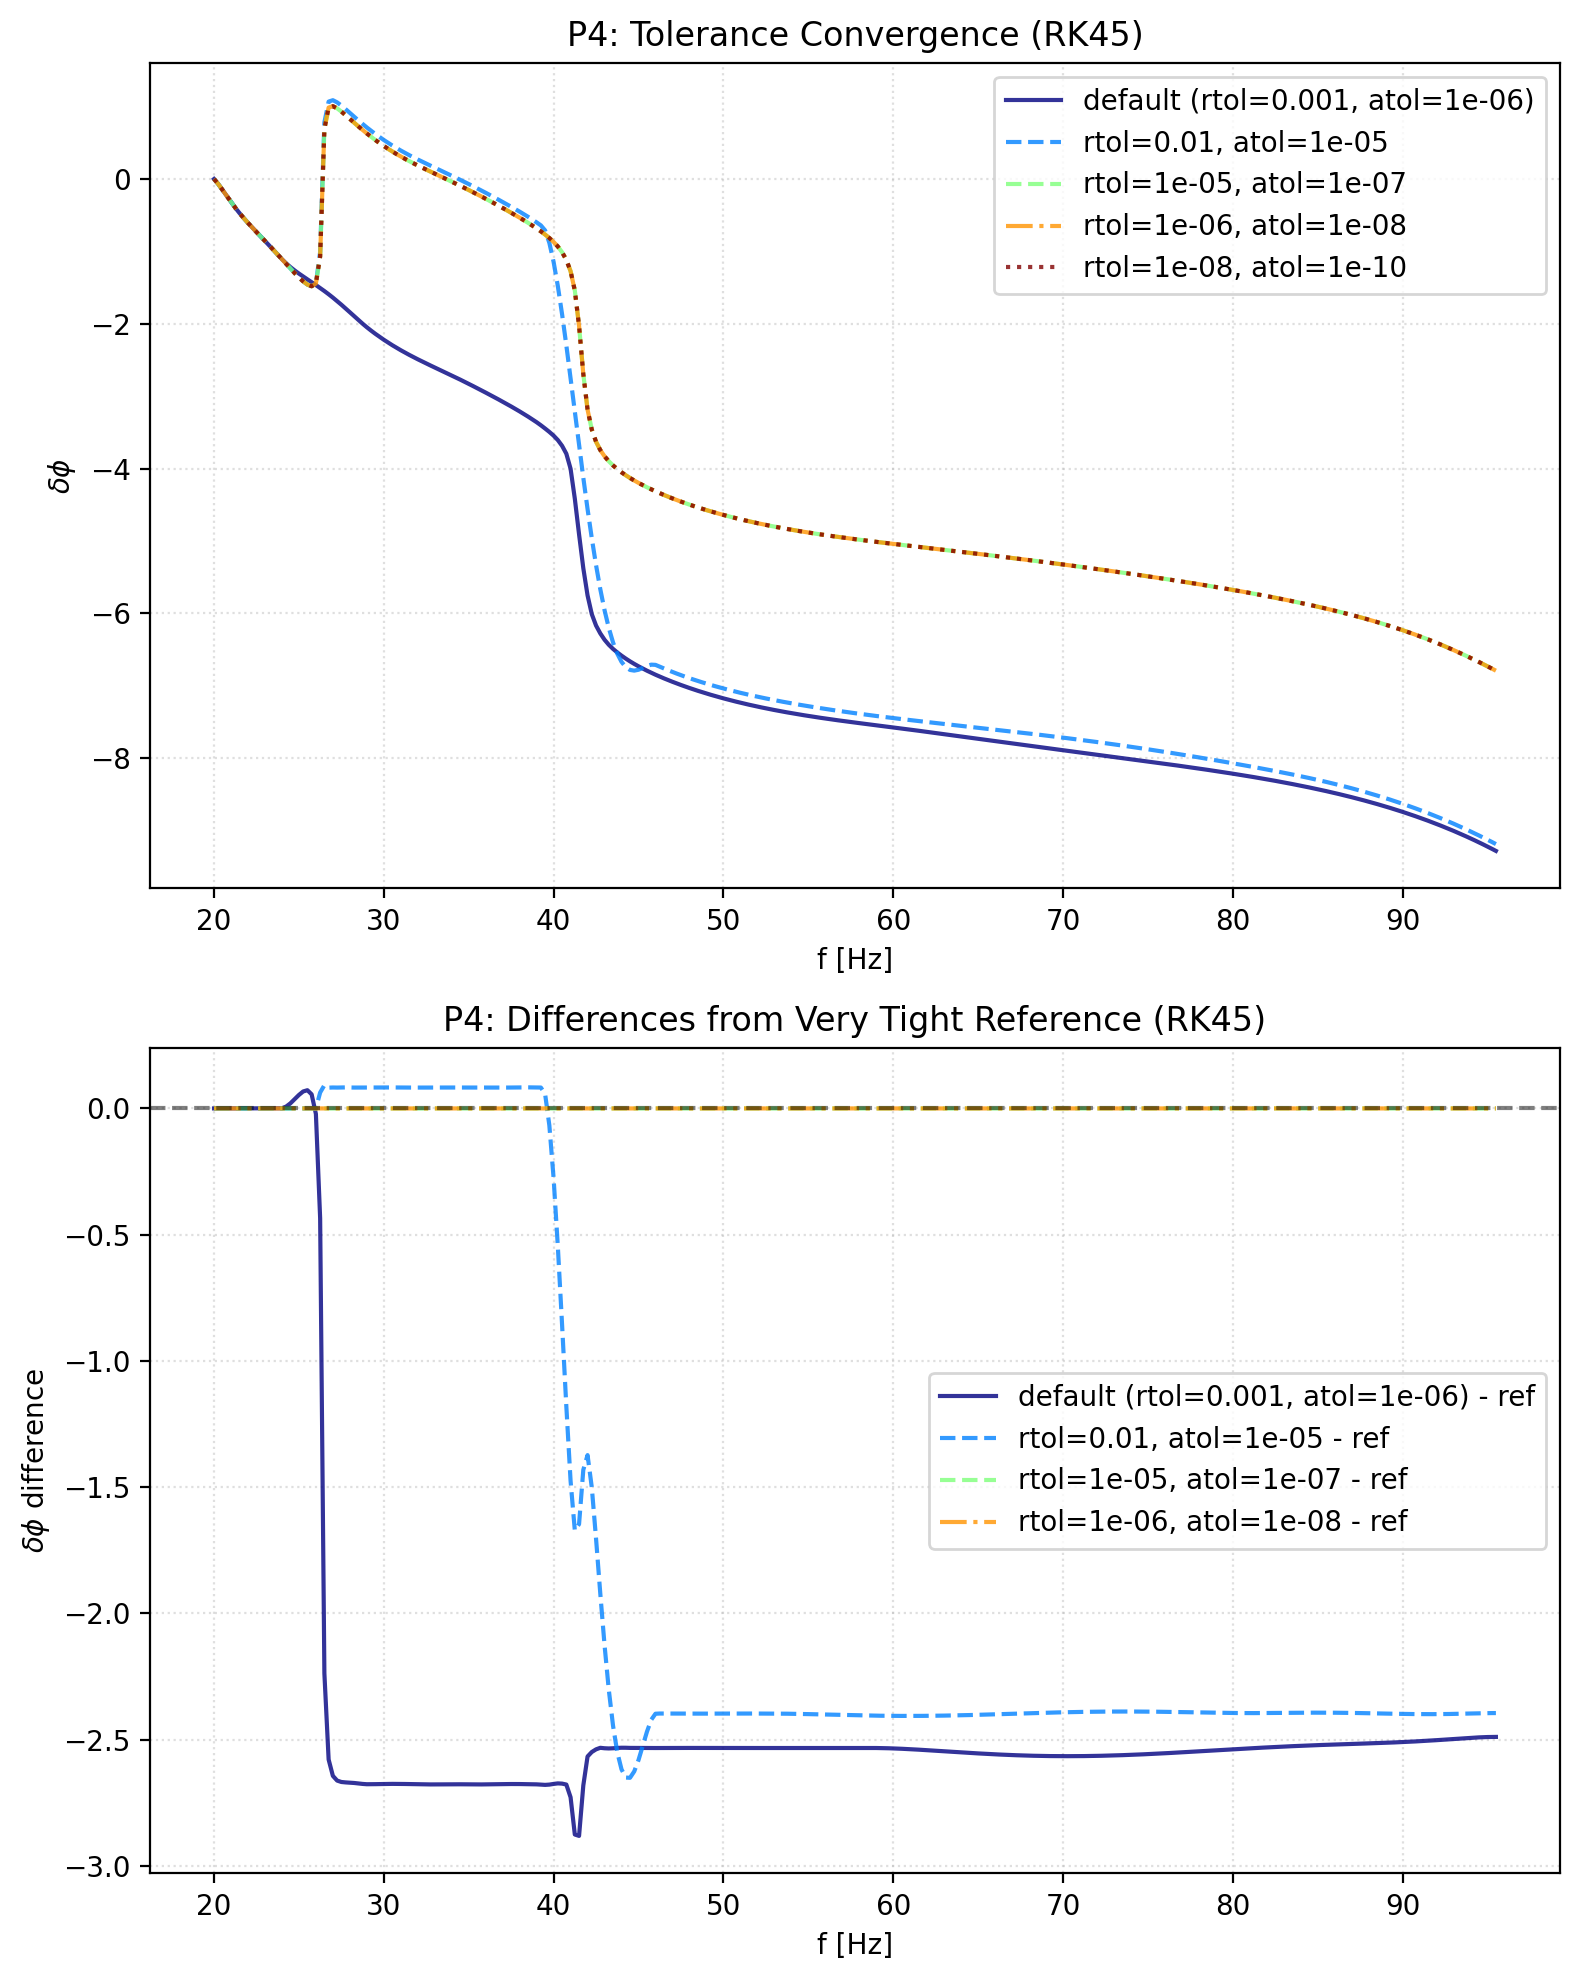

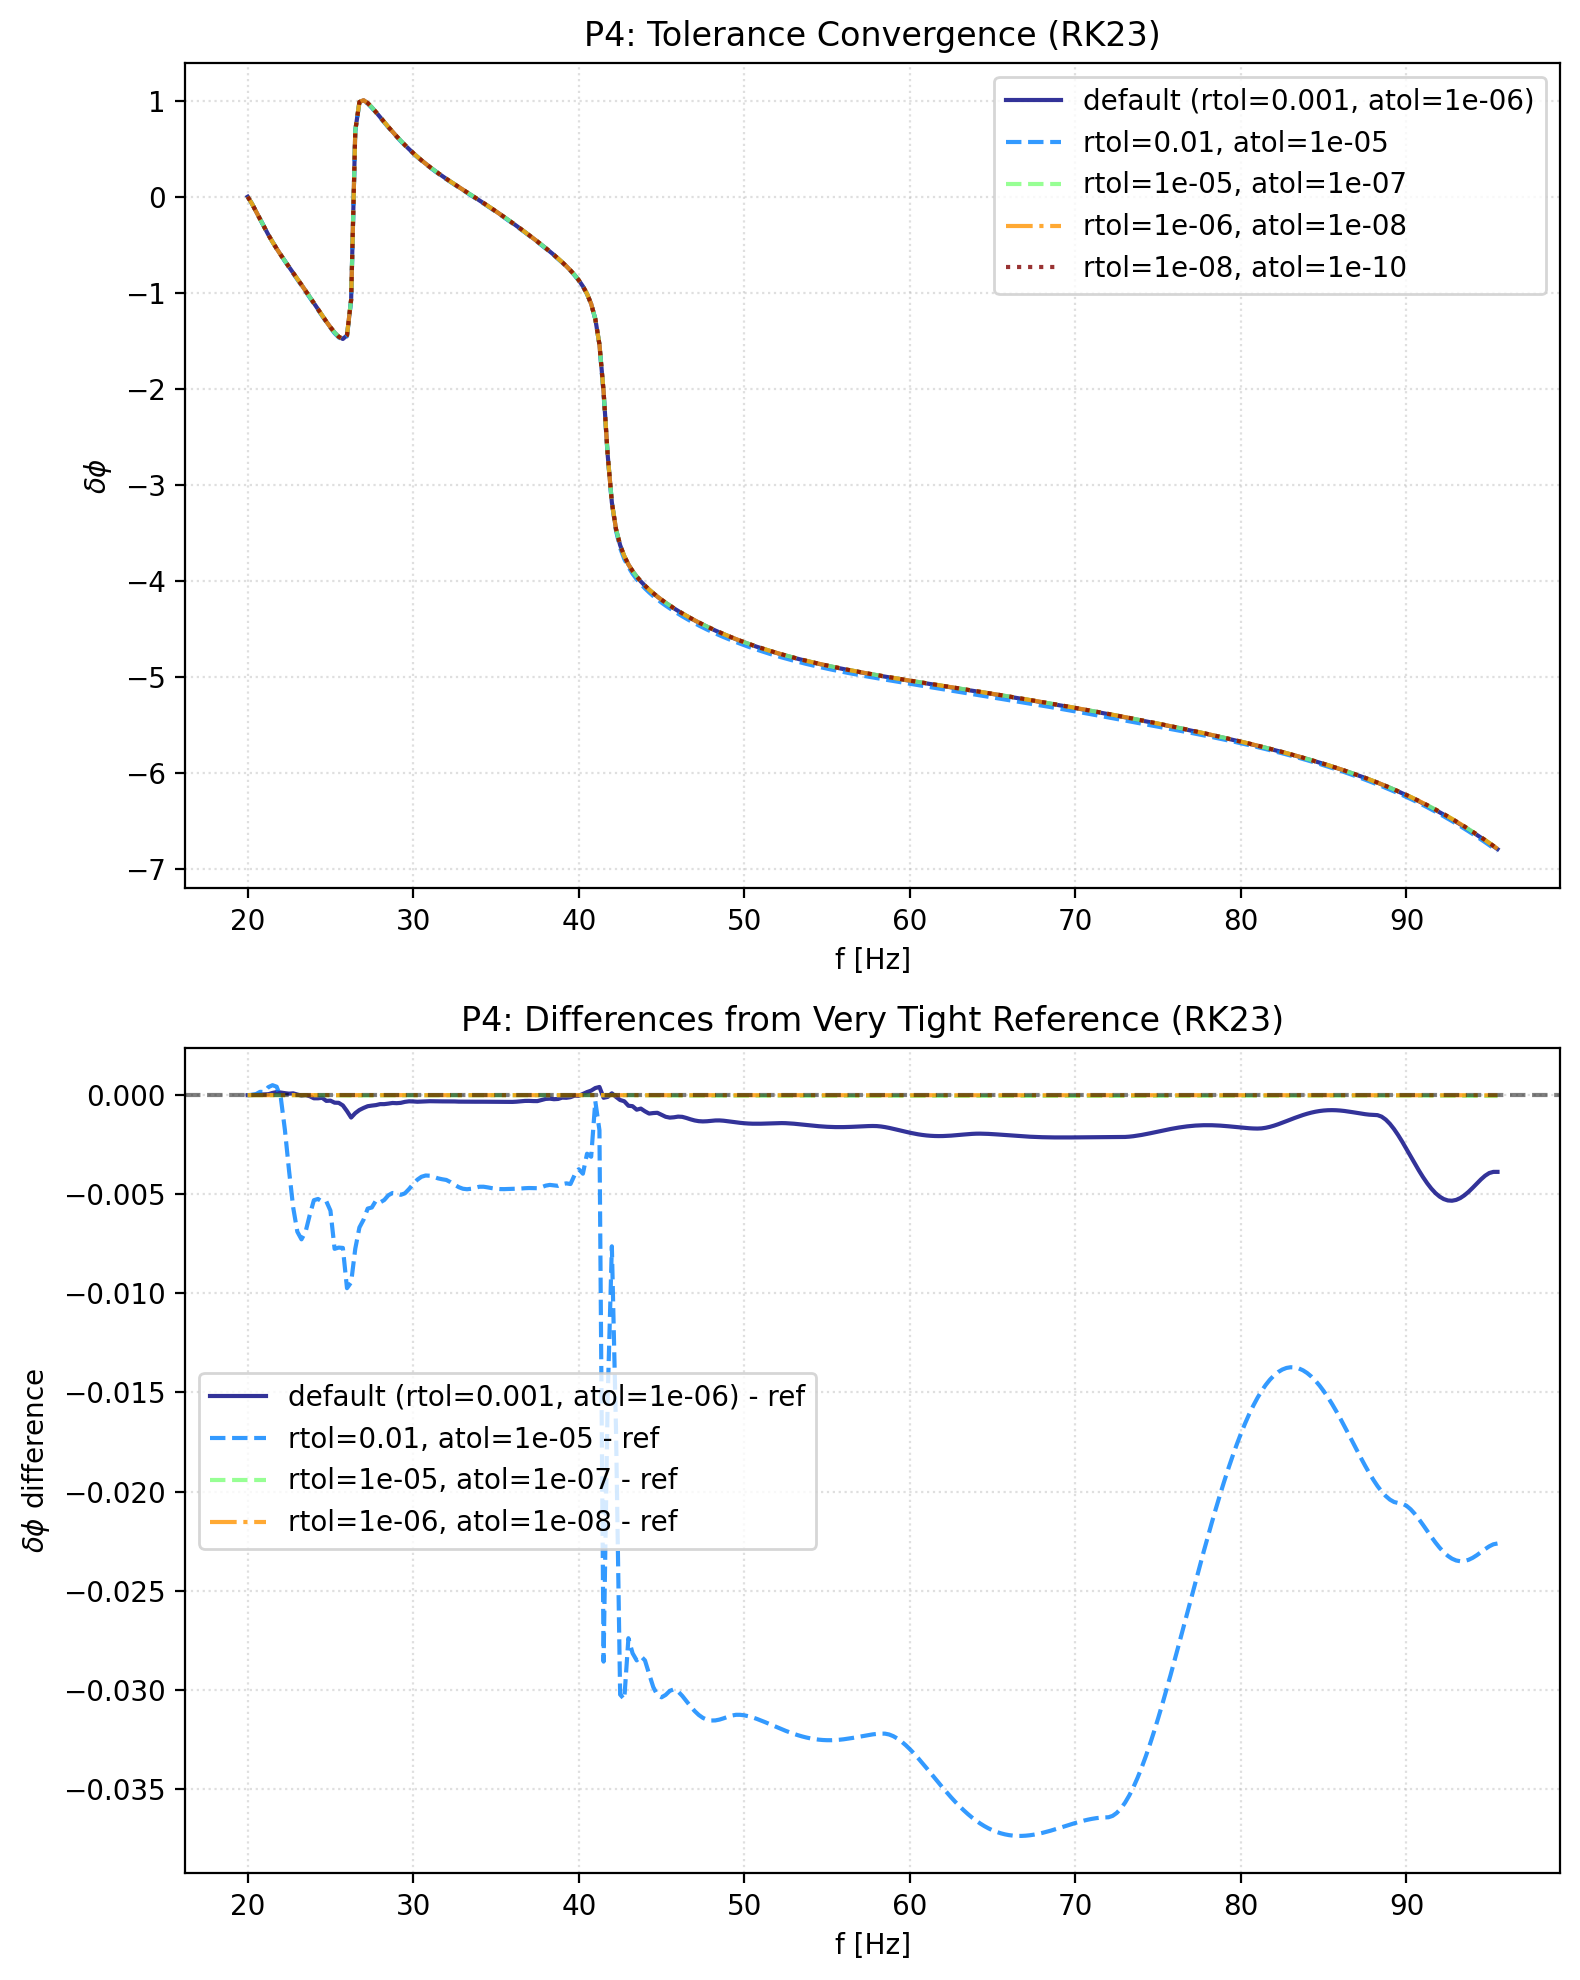

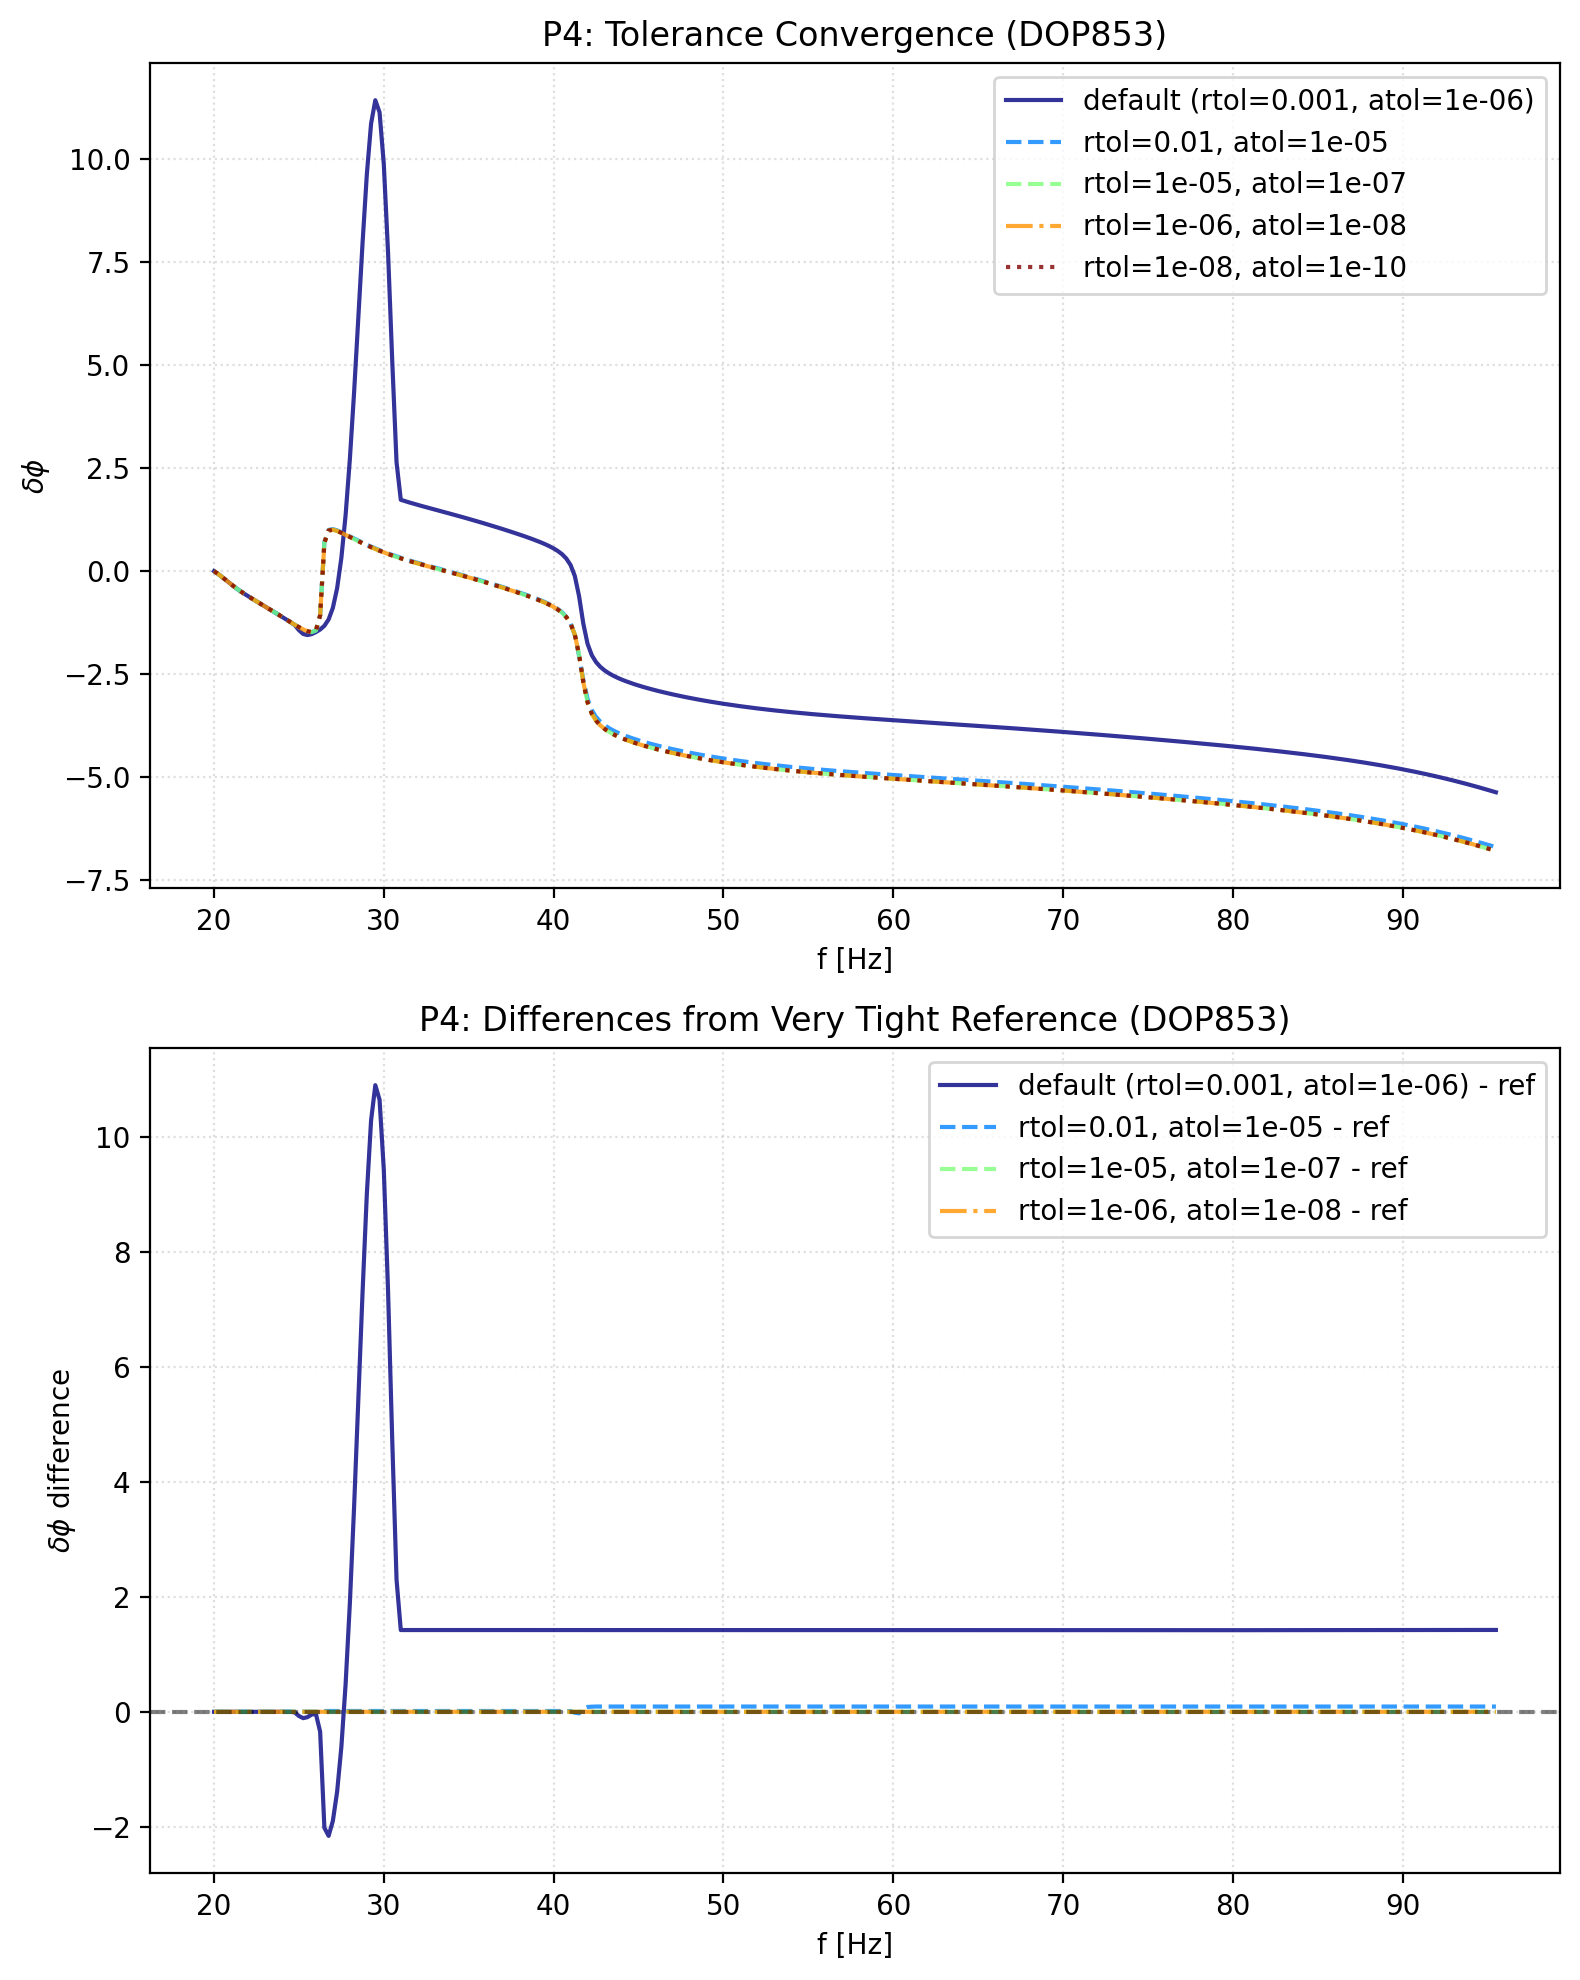

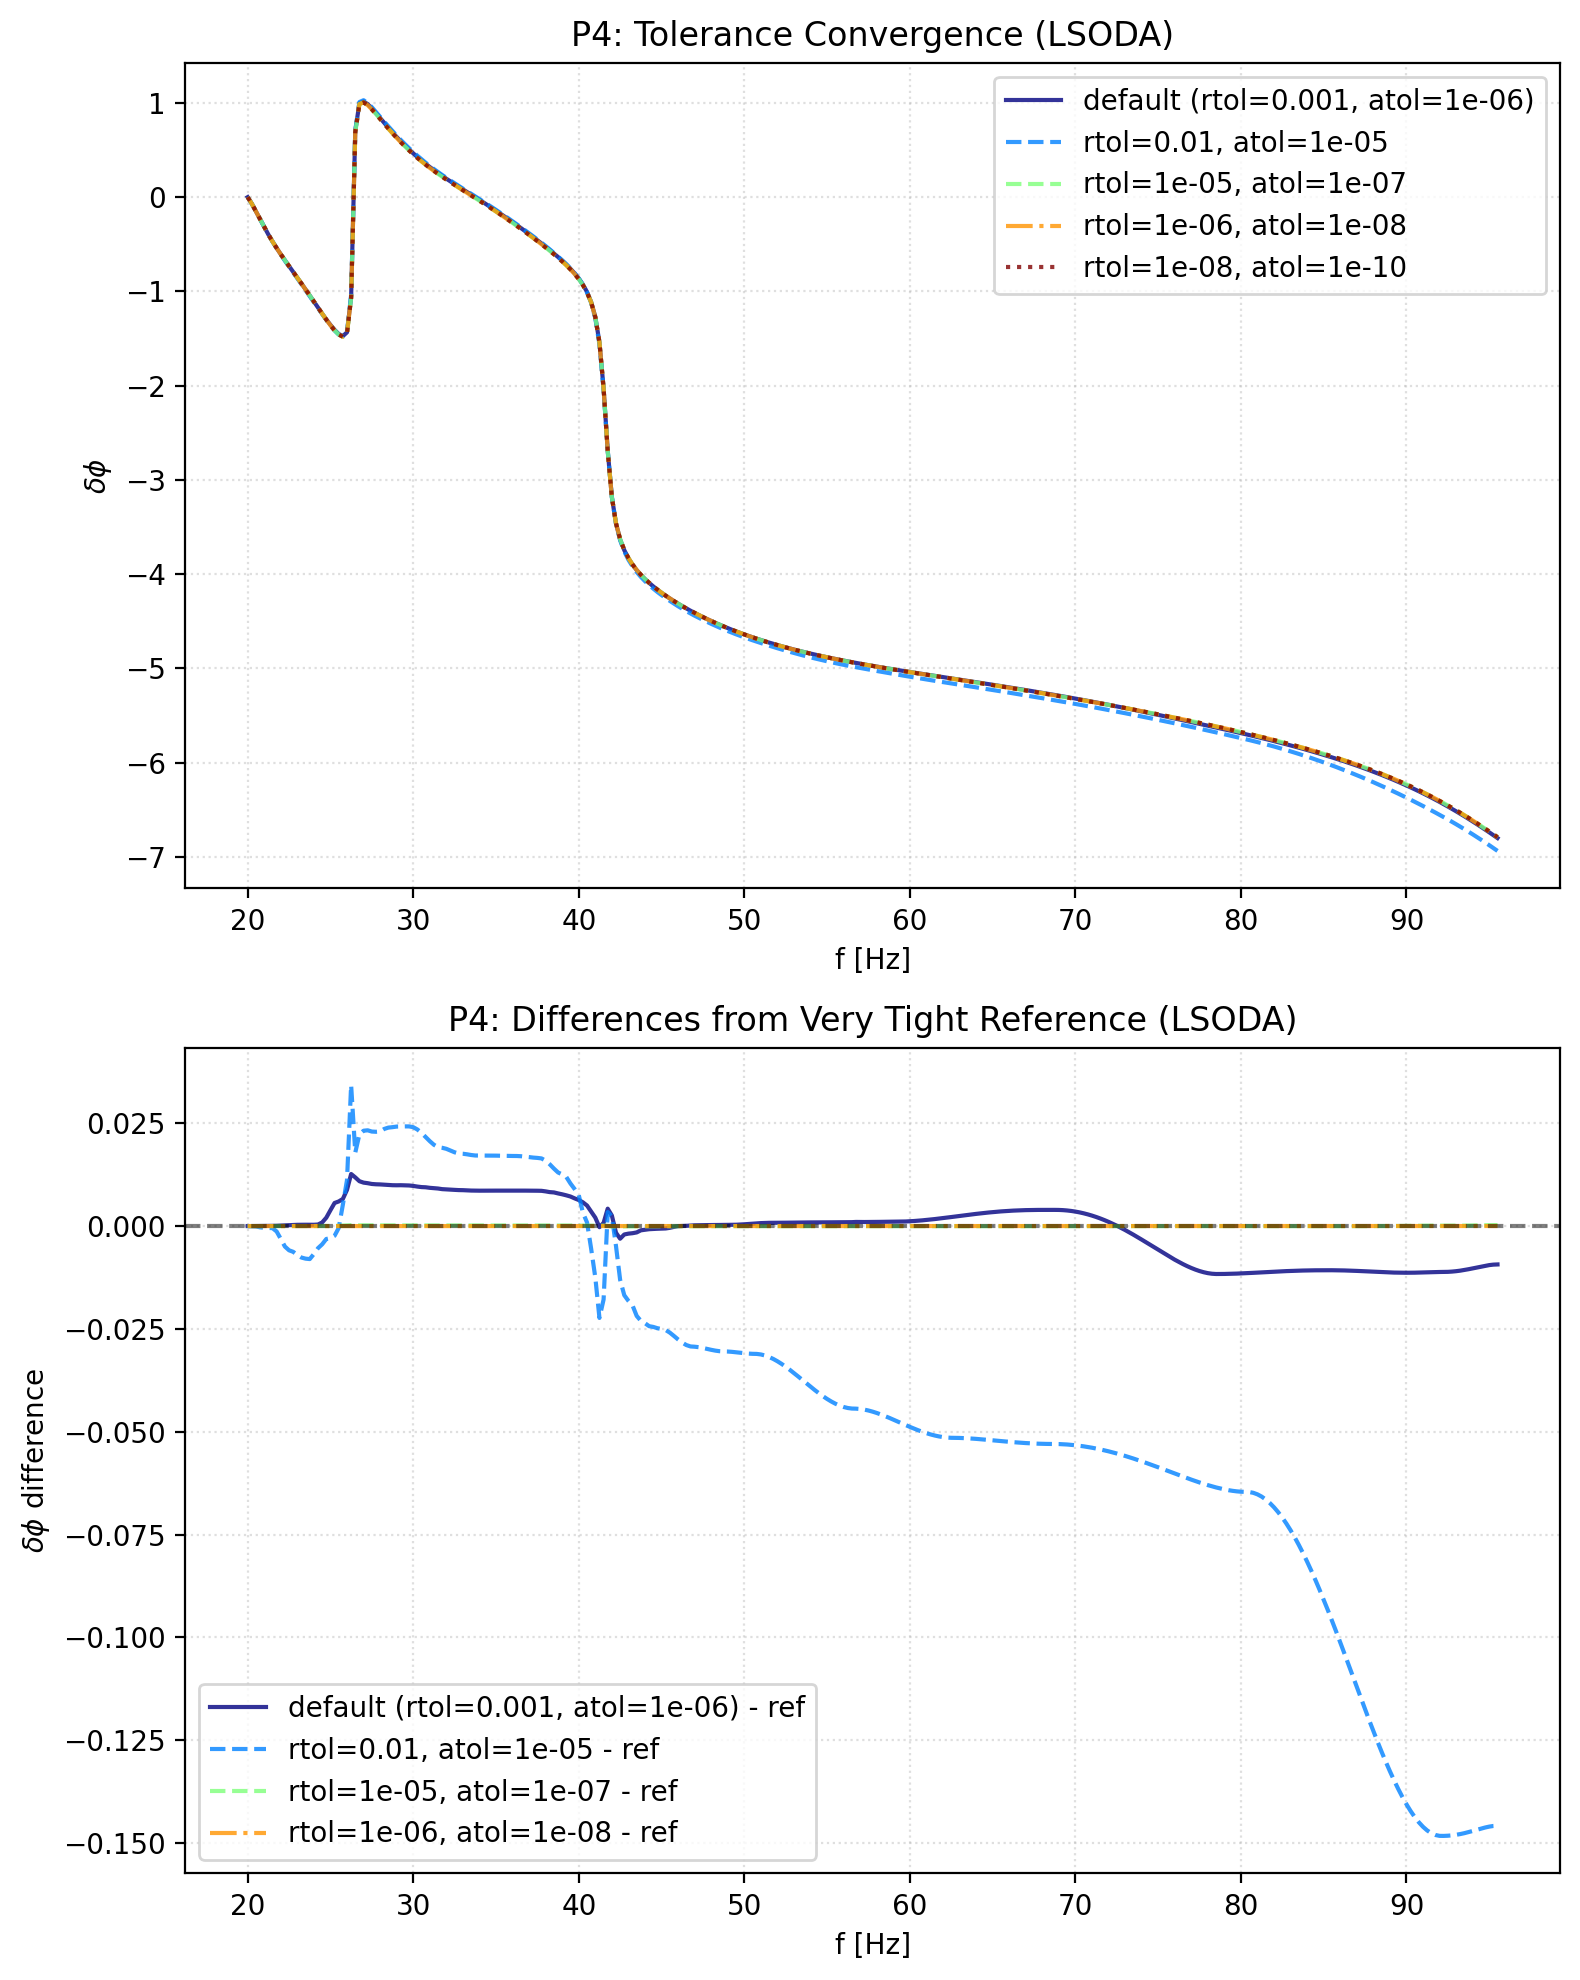

In [31]:
# Analyze convergence patterns

# Use the "Very Tight" tolerance as "reference" for each method
p2_ref = p2_results["Very Tight"]

# For P4, build a reference for each method
p4_refs = {}
for m in methods:
    ref_key = f"Very Tight-{m}"
    if ref_key in p4_results:
        p4_refs[m] = p4_results[ref_key]
    else:
        raise KeyError(f"Reference result for method {m} not found in p4_results.")

# Calculate differences from reference for P2
p2_diffs = {}
for name in p2_results:
    if name != "Very Tight":
        p2_diffs[name] = np.max(np.abs(p2_results[name] - p2_ref))

# Calculate differences from reference for P4 (for each method)
p4_diffs = {}
for name in p4_results:
    # name is like "Loose-RK45", "Very Tight-RK45", etc.
    for m in methods:
        ref_key = f"Very Tight-{m}"
        if name.endswith(f"-{m}") and name != ref_key:
            p4_diffs[name] = np.max(np.abs(p4_results[name] - p4_refs[m]))

# Calculate differences between P3 and references
p3_vs_p2_diff = np.max(np.abs(p3_phase - p2_ref))
# For P4, compare to each method's reference and report as a dict
p3_vs_p4_diff = {}
for m in methods:
    p3_vs_p4_diff[m] = np.max(np.abs(p3_phase - p4_refs[m]))

print("Convergence Analysis (Maximum differences from Very Tight reference):")
print("\nP2 convergence:")
for name, diff in p2_diffs.items():
    print(f"  {name:>12}: {diff:.2e}")

print("\nP4 convergence (by method):")
for m in methods:
    print(f"  Method: {m}")
    for name, _, _ in tolerance_sets:
        key = f"{name}-{m}"
        if key != f"Very Tight-{m}" and key in p4_diffs:
            print(f"    {name:>12}: {p4_diffs[key]:.2e}")

print(f"\nP3 vs P2 Very Tight: {p3_vs_p2_diff:.2e}")
for m in methods:
    print(f"P3 vs P4 Very Tight ({m}): {p3_vs_p4_diff[m]:.2e}")

# Create convergence plots

import matplotlib.pyplot as plt

colors = plt.cm.jet(np.linspace(0, 1, len(tolerance_sets)))
# Define linestyles for each tolerance level
linestyles = ["-", "--", "--", "-.", ":"]


# Helper: get numeric tolerance string for legend
def tol_label(rtol, atol, default_rtol, default_atol):
    if (rtol == default_rtol or rtol is None) and (
        atol == default_atol or atol is None
    ):
        return f"default (rtol={default_rtol:.3g}, atol={default_atol:.3g})"
    return f"rtol={rtol:.3g}, atol={atol:.3g}"


# Default tolerances for P2 and P4 (from their function signatures or documentation)
P2_DEFAULT_RTOL = 1.49012e-8
P2_DEFAULT_ATOL = 1.49012e-8
P4_DEFAULT_RTOL = 1e-3
P4_DEFAULT_ATOL = 1e-6

# Plot 1: P2 tolerance convergence
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(8, 10))

for i, (name, rtol, atol) in enumerate(tolerance_sets):
    label = tol_label(rtol, atol, P2_DEFAULT_RTOL, P2_DEFAULT_ATOL)
    ax1.plot(
        f_arr,
        p2_results[name],
        label=label,
        color=colors[i],
        lw=1.5,
        alpha=0.8,
        linestyle=linestyles[i % len(linestyles)],
    )
ax1.set_xlabel("f [Hz]")
ax1.set_ylabel("$\delta\phi$")
ax1.set_title("P2: Tolerance Convergence")
ax1.legend(loc="best", frameon=True, fancybox=True, framealpha=0.8)
ax1.grid(True, ls=":", alpha=0.4)

# Plot 3: P2 differences from reference
for i, (name, rtol, atol) in enumerate(tolerance_sets):
    if name != "Very Tight":
        label = f"{tol_label(rtol, atol, P2_DEFAULT_RTOL, P2_DEFAULT_ATOL)} - ref"
        diff = p2_results[name] - p2_ref
        ax3.plot(
            f_arr,
            diff,
            label=label,
            color=colors[i],
            lw=1.5,
            alpha=0.8,
            linestyle=linestyles[i % len(linestyles)],
        )
ax3.set_xlabel("f [Hz]")
ax3.set_ylabel("$\delta\phi$ difference")
ax3.set_title("P2: Differences from Very Tight Reference")
ax3.legend(loc="best", frameon=True, fancybox=True, framealpha=0.8)
ax3.grid(True, ls=":", alpha=0.4)
ax3.axhline(y=0, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Now, make a separate plot for each method in P4

for j, m in enumerate(methods):
    fig, (ax2, ax4) = plt.subplots(2, 1, figsize=(8, 10))
    # Plot 2: P4 tolerance convergence for this method
    for i, (name, rtol, atol) in enumerate(tolerance_sets):
        key = f"{name}-{m}"
        if key in p4_results:
            label = tol_label(rtol, atol, P4_DEFAULT_RTOL, P4_DEFAULT_ATOL)
            ax2.plot(
                f_arr,
                p4_results[key],
                label=label,
                color=colors[i],
                lw=1.5,
                alpha=0.8,
                linestyle=linestyles[i % len(linestyles)],
            )
    ax2.set_xlabel("f [Hz]")
    ax2.set_ylabel("$\delta\phi$")
    ax2.set_title(f"P4: Tolerance Convergence ({m})")
    ax2.legend(loc="best", frameon=True, fancybox=True, framealpha=0.8)
    ax2.grid(True, ls=":", alpha=0.4)

    # Plot 4: P4 differences from reference for this method
    ref = p4_refs[m]
    for i, (name, rtol, atol) in enumerate(tolerance_sets):
        key = f"{name}-{m}"
        if key != f"Very Tight-{m}" and key in p4_results:
            label = f"{tol_label(rtol, atol, P4_DEFAULT_RTOL, P4_DEFAULT_ATOL)} - ref"
            diff = p4_results[key] - ref
            ax4.plot(
                f_arr,
                diff,
                label=label,
                color=colors[i],
                lw=1.5,
                alpha=0.8,
                linestyle=linestyles[i % len(linestyles)],
            )
    ax4.set_xlabel("f [Hz]")
    ax4.set_ylabel("$\delta\phi$ difference")
    ax4.set_title(f"P4: Differences from Very Tight Reference ({m})")
    ax4.legend(loc="best", frameon=True, fancybox=True, framealpha=0.8)
    ax4.grid(True, ls=":", alpha=0.4)
    ax4.axhline(y=0, color="black", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()